# Prédire le ROI d'un film — modèle de régression

**Problématique** : une plateforme de streaming veut choisir son prochain type de film à produire. Quel retour sur investissement peut-elle espérer, et de quoi dépend-il ?

**Cible** : `log_roi`, le logarithme du ROI (recettes ÷ budget, en dollars constants 2023).

**Pourquoi le logarithme** : le ROI brut va de 0,003 à 12 890, avec une asymétrie de 82. Une régression sur la valeur brute serait pilotée par une poignée de cartons. En logarithme, la distribution devient symétrique, l'erreur devient multiplicative (se tromper d'un facteur 2 coûte pareil vers le haut et vers le bas), et les coefficients se lisent en pourcentage.

**Périmètre** : 9 268 films de cinéma présents dans MovieLens, TMDB et IMDb, avec budget et recettes renseignés.

**Règle anti-fuite** : aucune variable connue après la sortie (recettes, votes, popularité, notes MovieLens). La notoriété du réalisateur et des acteurs est calculée uniquement sur leurs films antérieurs.

**Démarche**
1. Données et cible
2. Analyse exploratoire
3. Protocole d'évaluation
4. Présélection : banc d'essai de 6 familles de modèles
5. Choix du modèle et justification
6. Réglage des hyperparamètres
7. Évaluation finale sur le test temporel
8. **Analyse des résidus**
9. Courbe d'apprentissage
10. Interprétabilité : importance par permutation et SHAP
11. Contrôle anti-fuite
12. Enregistrement du modèle retenu
13. Conclusions

La classification « rentable ou non » fait l'objet d'un notebook distinct.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import shap
from scipy import stats

from boxoffice import config
from boxoffice.features import success

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pio.renderers.default = "notebook"

data = success.charger()
variables = success.colonnes_variables(data)
print(f"{len(data):,} films | {len(variables)} variables")
data[["title", "year", "log_budget", "log_roi", "is_hit"]].head(3)

C:\Users\dyho\Documents\DataVis\projet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


9,268 films | 34 variables


,title,year,log_budget,log_roi,is_hit
0,Toy Story,1995,17.909646,3.468131,True
1,Jumanji,1995,18.682836,1.397089,True
2,Grumpier Old Men,1995,17.727325,1.051080,True


## 1. Données et cible

,ROI brut,log(ROI)
count,9268.00,9268.00
mean,6.80,0.30
std,142.51,1.74
min,0.00,-9.56
25%,0.62,-0.48
50%,1.76,0.57
75%,3.86,1.35
max,12890.39,9.46


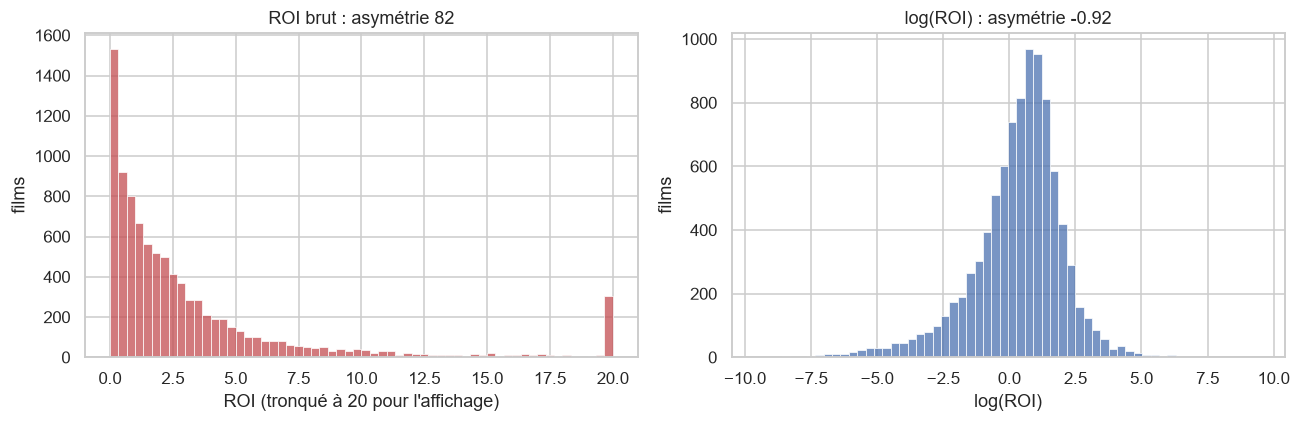

In [ ]:
roi = np.exp(data["log_roi"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(roi.clip(upper=20), bins=60, ax=axes[0], color="#C44E52")
axes[0].set(xlabel="ROI (tronqué à 20 pour l'affichage)", ylabel="films",
            title=f"ROI brut : asymétrie {stats.skew(roi):.0f}")
sns.histplot(data["log_roi"], bins=60, ax=axes[1], color="#4C72B0")
axes[1].set(xlabel="log(ROI)", ylabel="films", title=f"log(ROI) : asymétrie {stats.skew(data['log_roi']):.2f}")
plt.tight_layout()

pd.DataFrame({"ROI brut": roi.describe(), "log(ROI)": data["log_roi"].describe()}).round(2)

La transformation logarithmique est ce qui rend la régression possible : l'asymétrie passe de 82 à −0,9.

## 2. Analyse exploratoire

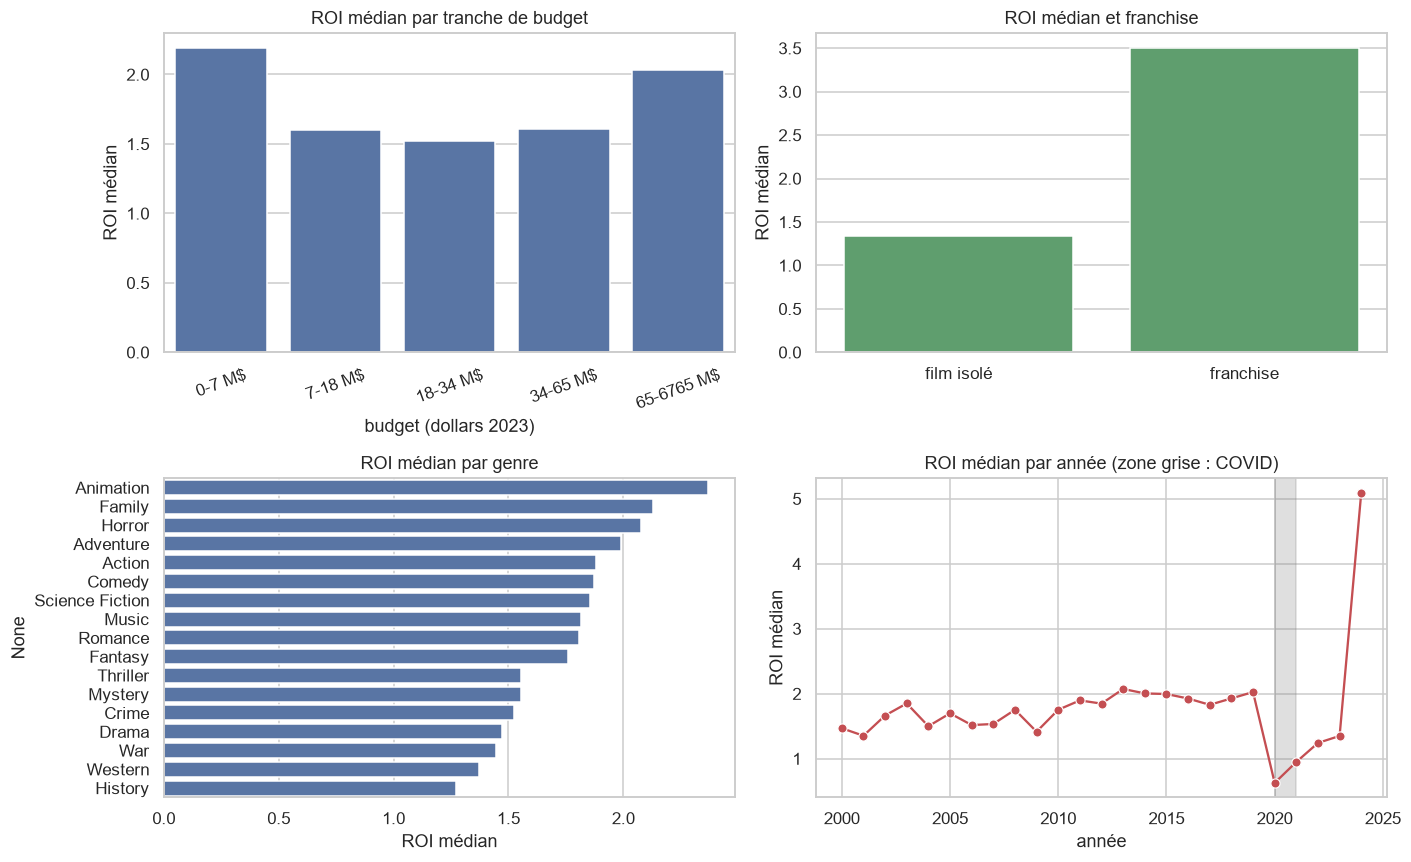

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

quintiles = pd.qcut(data["log_budget"], 5)
etiquettes = [f"{np.exp(i.left)/1e6:.0f}-{np.exp(i.right)/1e6:.0f} M$" for i in quintiles.cat.categories]
median_budget = data.groupby(quintiles, observed=True)["log_roi"].median().apply(np.exp)
sns.barplot(x=etiquettes, y=median_budget.values, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set(title="ROI médian par tranche de budget", ylabel="ROI médian", xlabel="budget (dollars 2023)")
axes[0, 0].tick_params(axis="x", rotation=20)

franchise = data.groupby("is_franchise")["log_roi"].median().apply(np.exp)
sns.barplot(x=["film isolé", "franchise"], y=franchise.values, ax=axes[0, 1], color="#55A868")
axes[0, 1].set(title="ROI médian et franchise", ylabel="ROI médian")

genres = [c for c in data.columns if c.startswith("genre_")]
medianes = {g[6:]: np.exp(data.loc[data[g] == 1, "log_roi"].median()) for g in genres if data[g].sum() >= 150}
medianes = pd.Series(medianes).sort_values(ascending=False)
sns.barplot(x=medianes.values, y=medianes.index, ax=axes[1, 0], color="#4C72B0")
axes[1, 0].set(title="ROI médian par genre", xlabel="ROI médian")

annees = data[data["year"] >= 2000].groupby("year")["log_roi"].median().apply(np.exp)
sns.lineplot(x=annees.index, y=annees.values, marker="o", ax=axes[1, 1], color="#C44E52")
axes[1, 1].axvspan(2020, 2021, color="grey", alpha=0.25)
axes[1, 1].set(title="ROI médian par année (zone grise : COVID)", xlabel="année", ylabel="ROI médian")
plt.tight_layout()

Deux enseignements : la relation budget-ROI est **en U**, ce qu'un modèle linéaire ne peut pas représenter ; et les années COVID marquent une rupture nette, qu'il faudra retrouver dans les résidus.

## 3. Protocole d'évaluation

| | Rôle | Mise en œuvre |
|---|---|---|
| **Découpage temporel** | mesurer la performance sur des films jamais vus | entraînement avant 2018, test à partir de 2018 |
| **Validation croisée** | comparer et régler les modèles | 5 blocs sur le seul jeu d'entraînement |

Le test n'est utilisé qu'à la toute fin, une seule fois.

**Métriques**, nommées comme dans scikit-learn :

| Métrique | Lecture |
|---|---|
| **MAE** (erreur absolue moyenne, sur le log) | erreur typique, peu sensible aux extrêmes |
| **facteur d'erreur** = exp(MAE) | « le modèle se trompe d'un facteur X » : la métrique à montrer au métier |
| **RMSE** | pénalise les grosses erreurs |
| **R²** | part de la variance expliquée ; négatif = pire que prédire la médiane |

In [ ]:
categorielles = ["saison", "langue", "pays", "studio"]
numeriques = [c for c in variables if c not in categorielles]
indices_categoriels = [variables.index(c) for c in categorielles]

X = data[variables].copy()
for colonne in variables:
    X[colonne] = (X[colonne].astype("category").cat.codes.astype("float64")
                  if colonne in categorielles else X[colonne].astype("float64"))
y = data["log_roi"].astype(float)

train, test = success.decoupage_temporel(data)
i_train, i_test = train.index, test.index
print(f"entraînement : {len(i_train):,} films (avant 2018) | test : {len(i_test):,} films (2018 et après)")
print(f"ROI médian : {np.exp(y[i_train].median()):.2f} en entraînement, {np.exp(y[i_test].median()):.2f} en test")

entraînement : 8,285 films (avant 2018) | test : 983 films (2018 et après)
ROI médian : 1.80 en entraînement, 1.39 en test


## 4. Présélection : banc d'essai de 6 familles de modèles

| Famille | Hypothèse testée |
|---|---|
| Référence (médiane) | plancher obligatoire |
| Régression linéaire régularisée (Ridge) | les effets sont-ils linéaires ? |
| Lasso | une sélection automatique de variables aide-t-elle ? |
| k plus proches voisins | les films semblables ont-ils le même ROI ? |
| Forêt aléatoire | un ensemble d'arbres décorrélés |
| Gradient boosting | des arbres qui corrigent les erreurs précédentes |

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import KFold, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preparation = ColumnTransformer([
    ("num", Pipeline([("imputation", SimpleImputer(strategy="median")), ("echelle", StandardScaler())]), numeriques),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorielles),
])

candidats = {
    "référence (médiane)": DummyRegressor(strategy="median"),
    "Ridge": Pipeline([("prep", preparation), ("modele", Ridge(alpha=1.0))]),
    "Lasso": Pipeline([("prep", preparation), ("modele", Lasso(alpha=0.01))]),
    "k plus proches voisins": Pipeline([("prep", preparation), ("modele", KNeighborsRegressor(n_neighbors=25))]),
    "forêt aléatoire": Pipeline([("imputation", SimpleImputer(strategy="median")),
                                 ("modele", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    "gradient boosting": HistGradientBoostingRegressor(categorical_features=indices_categoriels, random_state=42),
}

cv = KFold(5, shuffle=True, random_state=42)
banc, scores_par_bloc = [], {}
for nom, modele in candidats.items():
    resultat = cross_validate(modele, X.loc[i_train], y[i_train], cv=cv,
                              scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"], n_jobs=1)
    mae = -resultat["test_neg_mean_absolute_error"].mean()
    scores_par_bloc[nom] = -resultat["test_neg_mean_absolute_error"]
    banc.append({"modèle": nom, "MAE": mae, "MAE std": resultat["test_neg_mean_absolute_error"].std(),
                 "facteur d'erreur": np.exp(mae),
                 "RMSE": -resultat["test_neg_root_mean_squared_error"].mean(),
                 "R2": resultat["test_r2"].mean(),
                 "fit time (s)": resultat["fit_time"].mean()})

banc = pd.DataFrame(banc).set_index("modèle").sort_values("MAE")
banc.round(3)

,MAE,MAE std,facteur d'erreur,RMSE,R2,fit time (s)
modèle,,,,,,
gradient boosting,1.100,0.024,3.004,1.517,0.219,0.431
forêt aléatoire,1.121,0.026,3.068,1.541,0.194,1.876
Lasso,1.133,0.024,3.106,1.566,0.169,0.054
Ridge,1.134,0.026,3.108,1.563,0.171,0.057
k plus proches voisins,1.163,0.027,3.199,1.599,0.133,0.052
référence (médiane),1.236,0.019,3.442,1.736,-0.022,0.015


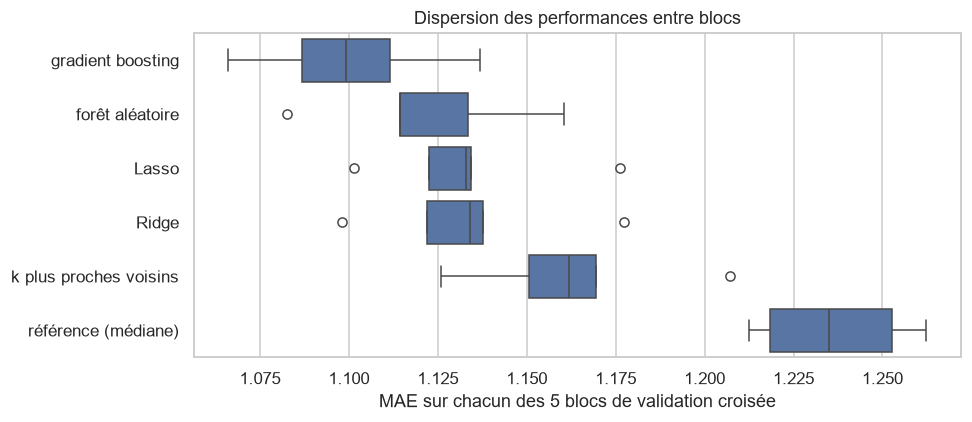

In [ ]:
plt.figure(figsize=(9, 4))
ordre = banc.index.tolist()
sns.boxplot(data=[scores_par_bloc[nom] for nom in ordre], orient="h", color="#4C72B0")
plt.yticks(range(len(ordre)), ordre)
plt.xlabel("MAE sur chacun des 5 blocs de validation croisée")
plt.title("Dispersion des performances entre blocs")
plt.tight_layout()

## 5. Choix du modèle et justification

**À lire dans le tableau ci-dessus :**
- le **gradient boosting** devrait arriver en tête : il capte la forme en U du budget et gère nativement valeurs manquantes et catégories ;
- **Ridge** sert de modèle d'explication : ses coefficients se lisent directement en pourcentage de ROI ;
- **la référence** montre le plancher : un R² proche de 0 signifie « ne fait pas mieux que prédire la médiane pour tout le monde » ;
- **le R² restera modeste**, et c'est le résultat honnête : le box-office est intrinsèquement incertain. Ce constat est plus intéressant qu'un score gonflé.

**Décision : gradient boosting pour prédire, Ridge pour expliquer.**

## 6. Réglage des hyperparamètres

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

grille = {
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 40],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0],
    "max_iter": [200, 400],
}

recherche = RandomizedSearchCV(
    HistGradientBoostingRegressor(categorical_features=indices_categoriels, early_stopping=True, random_state=42),
    grille, n_iter=25, scoring="neg_mean_absolute_error", cv=cv, random_state=42, n_jobs=-1)
recherche.fit(X.loc[i_train], y[i_train])

print("meilleurs paramètres :")
for parametre, valeur in sorted(recherche.best_params_.items()):
    print(f"  {parametre} = {valeur}")
print(f"\nMAE validation croisée : {-recherche.best_score_:.3f} "
      f"(réglages par défaut : {banc.loc['gradient boosting', 'MAE']:.3f})")

meilleurs paramètres :
  l2_regularization = 10.0
  learning_rate = 0.05
  max_iter = 200
  max_leaf_nodes = 31
  min_samples_leaf = 10

MAE validation croisée : 1.099 (réglages par défaut : 1.100)


## 7. Évaluation finale sur le test temporel

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

finalistes = {
    "référence (médiane)": candidats["référence (médiane)"],
    "Ridge": candidats["Ridge"],
    "gradient boosting réglé": recherche.best_estimator_,
}

evaluation, predictions = [], {}
for nom, modele in finalistes.items():
    modele.fit(X.loc[i_train], y[i_train])
    prediction = modele.predict(X.loc[i_test])
    predictions[nom] = prediction
    mae = mean_absolute_error(y[i_test], prediction)
    evaluation.append({"modèle": nom, "MAE": mae, "facteur d'erreur": np.exp(mae),
                       "RMSE": root_mean_squared_error(y[i_test], prediction),
                       "R2": r2_score(y[i_test], prediction)})

pd.DataFrame(evaluation).set_index("modèle").round(3)

,MAE,facteur d'erreur,RMSE,R2
modèle,,,,
référence (médiane),1.410,4.095,1.980,-0.082
Ridge,1.261,3.530,1.802,0.104
gradient boosting réglé,1.227,3.410,1.754,0.151


étendue des prédictions : 0.11 à 72.83 | étendue réelle : 0.00 à 559.09


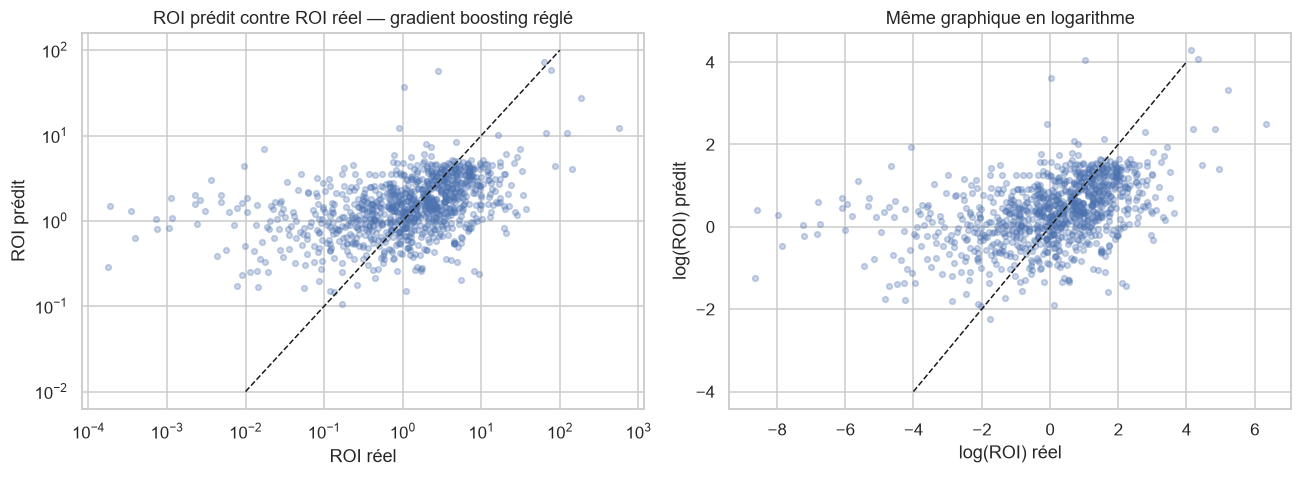

In [ ]:
retenu = "gradient boosting réglé"
reel, predit = np.exp(y[i_test]), np.exp(predictions[retenu])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(reel, predit, alpha=0.3, s=14, color="#4C72B0")
axes[0].plot([0.01, 100], [0.01, 100], "k--", linewidth=1)
axes[0].set(xscale="log", yscale="log", xlabel="ROI réel", ylabel="ROI prédit",
            title=f"ROI prédit contre ROI réel — {retenu}")

axes[1].scatter(y[i_test], predictions[retenu], alpha=0.3, s=14, color="#4C72B0")
axes[1].plot([-4, 4], [-4, 4], "k--", linewidth=1)
axes[1].set(xlabel="log(ROI) réel", ylabel="log(ROI) prédit", title="Même graphique en logarithme")
plt.tight_layout()

print(f"étendue des prédictions : {predit.min():.2f} à {predit.max():.2f} | "
      f"étendue réelle : {reel.min():.2f} à {reel.max():.2f}")

Le modèle **écrase les extrêmes** : il ne prédit jamais ni les désastres ni les cartons. C'est le comportement normal d'un modèle qui minimise une erreur moyenne, et c'est une limite à annoncer.

## 8. Analyse des résidus

Un résidu, c'est l'écart entre la valeur réelle et la valeur prédite. On veut un nuage **sans structure** : si les erreurs dépendent encore d'une variable, c'est qu'il manque de l'information au modèle.

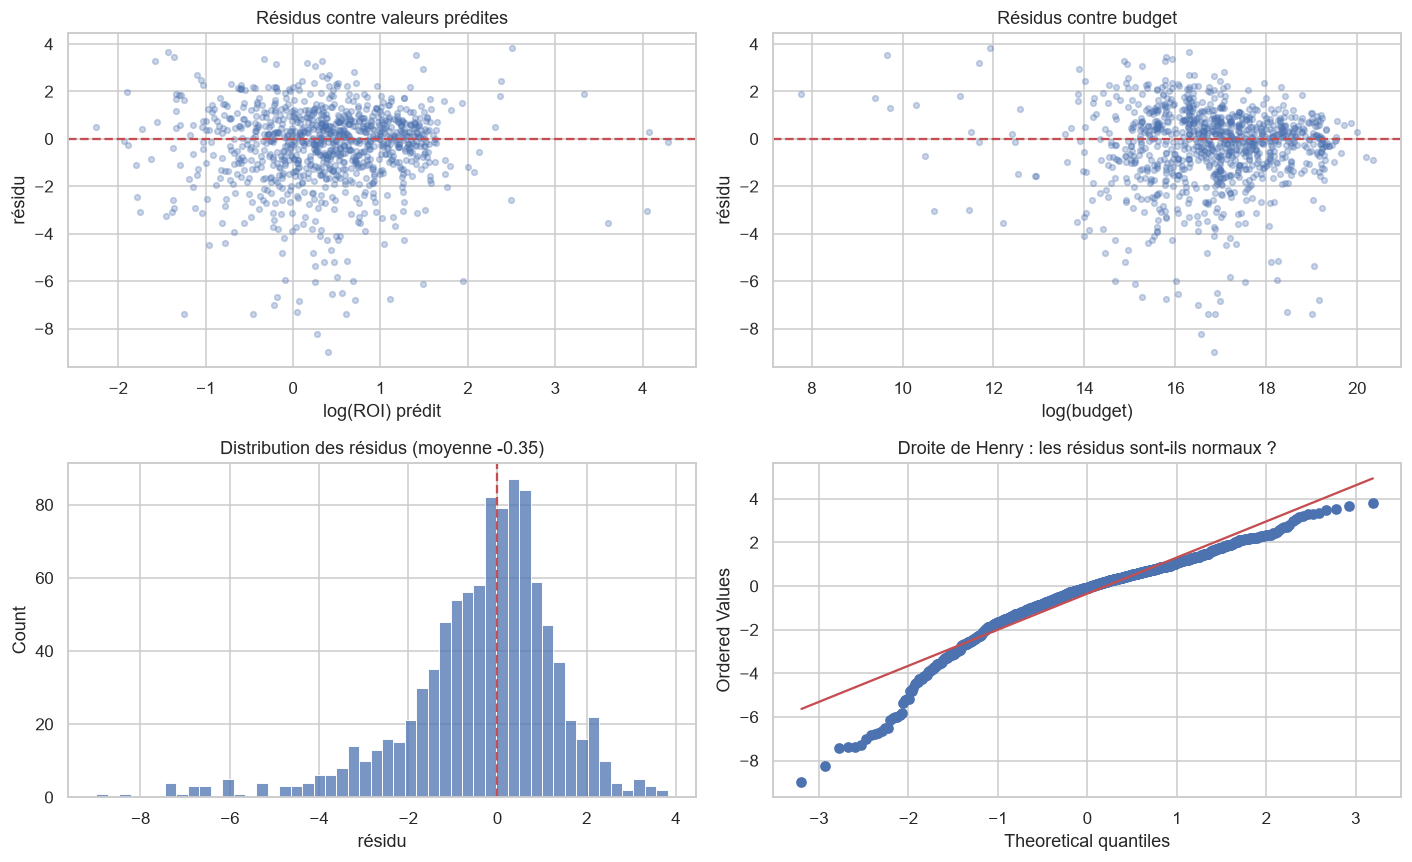

In [ ]:
residus = pd.DataFrame({
    "film": data.loc[i_test, "title"].values,
    "annee": data.loc[i_test, "year"].values,
    "log_budget": data.loc[i_test, "log_budget"].values,
    "predit": predictions[retenu],
    "reel": y[i_test].values,
})
residus["residu"] = residus["reel"] - residus["predit"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].scatter(residus["predit"], residus["residu"], alpha=0.3, s=14, color="#4C72B0")
axes[0, 0].axhline(0, color="#C44E52", linestyle="--")
axes[0, 0].set(xlabel="log(ROI) prédit", ylabel="résidu", title="Résidus contre valeurs prédites")

axes[0, 1].scatter(residus["log_budget"], residus["residu"], alpha=0.3, s=14, color="#4C72B0")
axes[0, 1].axhline(0, color="#C44E52", linestyle="--")
axes[0, 1].set(xlabel="log(budget)", ylabel="résidu", title="Résidus contre budget")

sns.histplot(residus["residu"], bins=50, ax=axes[1, 0], color="#4C72B0")
axes[1, 0].axvline(0, color="#C44E52", linestyle="--")
axes[1, 0].set(xlabel="résidu", title=f"Distribution des résidus (moyenne {residus['residu'].mean():.2f})")

stats.probplot(residus["residu"], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Droite de Henry : les résidus sont-ils normaux ?")
plt.tight_layout()

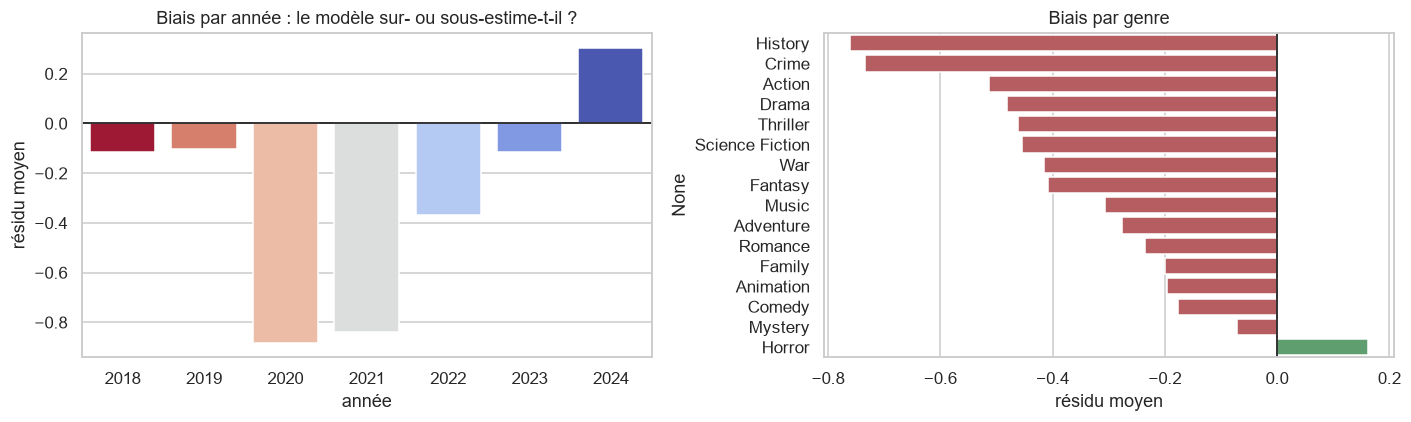

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

par_annee = residus.groupby("annee")["residu"].agg(["mean", "size"])
sns.barplot(x=par_annee.index.astype(int), y=par_annee["mean"], ax=axes[0],
            hue=par_annee.index.astype(int), palette="coolwarm_r", legend=False)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(xlabel="année", ylabel="résidu moyen", title="Biais par année : le modèle sur- ou sous-estime-t-il ?")

genres = [c for c in data.columns if c.startswith("genre_")]
biais = {g[6:]: residus.loc[data.loc[i_test, g].values == 1, "residu"].mean()
         for g in genres if data.loc[i_test, g].sum() >= 30}
biais = pd.Series(biais).sort_values()
sns.barplot(x=biais.values, y=biais.index, ax=axes[1], hue=biais.index,
            palette=["#C44E52" if v < 0 else "#55A868" for v in biais.values], legend=False)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(xlabel="résidu moyen", title="Biais par genre")
plt.tight_layout()

**Comment lire ces quatre graphiques :**

| Ce qu'on observe | Ce que ça signifie |
|---|---|
| Nuage sans forme, centré sur 0 | le modèle n'a pas de biais systématique |
| Une pente ou une courbe | un effet non capté, il manque une variable ou une transformation |
| Un entonnoir | variance non constante : les prédictions sont moins fiables sur une plage |
| Résidus décalés une année | rupture de marché, typiquement 2020-2021 |
| Biais par genre | le modèle se trompe systématiquement sur ce type de film |

**Les années COVID sont le test décisif** : si le résidu moyen y est nettement négatif, le modèle surestime le ROI de ces films, et l'erreur vient de la rupture du marché, pas du modèle.

In [ ]:
figure = px.scatter(
    residus, x="predit", y="residu", color="annee", color_continuous_scale="RdYlBu",
    hover_name="film", hover_data={"annee": True, "reel": ":.2f", "predit": ":.2f", "residu": ":.2f"},
    labels={"predit": "log(ROI) prédit", "residu": "résidu", "annee": "année"},
    title="Résidus film par film : survoler pour identifier les cas extrêmes")
figure.add_hline(y=0, line_dash="dash", line_color="grey")
figure.update_layout(height=520)
figure.show()

In [ ]:
print("Les 5 films les plus sous-estimés (succès inattendus) :")
print(residus.nlargest(5, "residu")[["film", "annee", "reel", "predit", "residu"]].round(2).to_string(index=False))
print()
print("Les 5 films les plus surestimés (échecs inattendus) :")
print(residus.nsmallest(5, "residu")[["film", "annee", "reel", "predit", "residu"]].round(2).to_string(index=False))

Les 5 films les plus sous-estimés (succès inattendus) :
             film  annee  reel  predit  residu
     Animal World   2018  6.33    2.51    3.82
    Triple Threat   2019  2.24   -1.43    3.67
      Skinamarink   2022  4.96    1.41    3.55
      Breaking In   2018  2.10   -1.37    3.47
The Invisible Man   2020  3.03   -0.33    3.36

Les 5 films les plus surestimés (échecs inattendus) :
                  film  annee  reel  predit  residu
    The Spy Gone North   2018 -8.59    0.40   -8.99
Kickboxer: Retaliation   2018 -7.96    0.28   -8.24
            Red Notice   2021 -6.80    0.61   -7.41
           The Fanatic   2019 -8.65   -1.25   -7.40
           Speed Kills   2018 -7.86   -0.46   -7.40


## 9. Courbe d'apprentissage

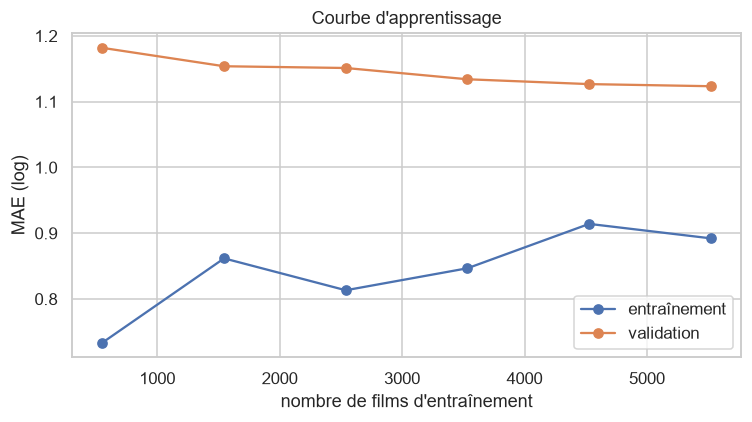

In [ ]:
from sklearn.model_selection import learning_curve

tailles, score_train, score_val = learning_curve(
    recherche.best_estimator_, X.loc[i_train], y[i_train], cv=3, scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=42)

plt.figure(figsize=(7, 4))
plt.plot(tailles, -score_train.mean(axis=1), marker="o", label="entraînement")
plt.plot(tailles, -score_val.mean(axis=1), marker="o", label="validation")
plt.xlabel("nombre de films d'entraînement")
plt.ylabel("MAE (log)")
plt.title("Courbe d'apprentissage")
plt.legend()
plt.tight_layout()

## 10. Interprétabilité

Les 5 variables les plus importantes :
  1. is_franchise (0.1098)
  2. log_budget (0.0799)
  3. director_taux_hits_avant (0.0306)
  4. age_min (0.0289)
  5. pays (0.0249)


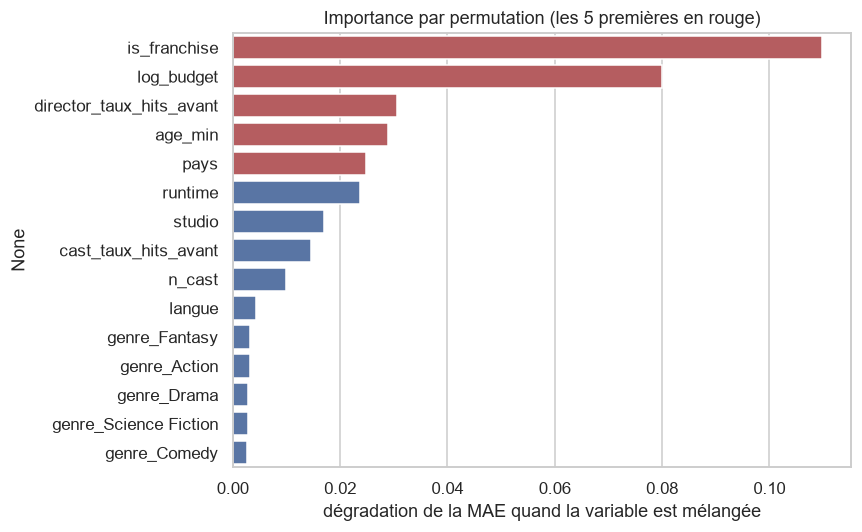

In [ ]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(recherche.best_estimator_, X.loc[i_test], y[i_test],
                                    scoring="neg_mean_absolute_error", n_repeats=10, random_state=42)
classement = pd.Series(importance.importances_mean, index=variables).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
couleurs = ["#C44E52" if rang < 5 else "#4C72B0" for rang in range(len(classement))]
sns.barplot(x=classement.values, y=classement.index, hue=classement.index, palette=couleurs, legend=False)
plt.xlabel("dégradation de la MAE quand la variable est mélangée")
plt.title("Importance par permutation (les 5 premières en rouge)")
plt.tight_layout()

print("Les 5 variables les plus importantes :")
for rang, (nom, valeur) in enumerate(classement.head(5).items(), 1):
    print(f"  {rang}. {nom} ({valeur:.4f})")

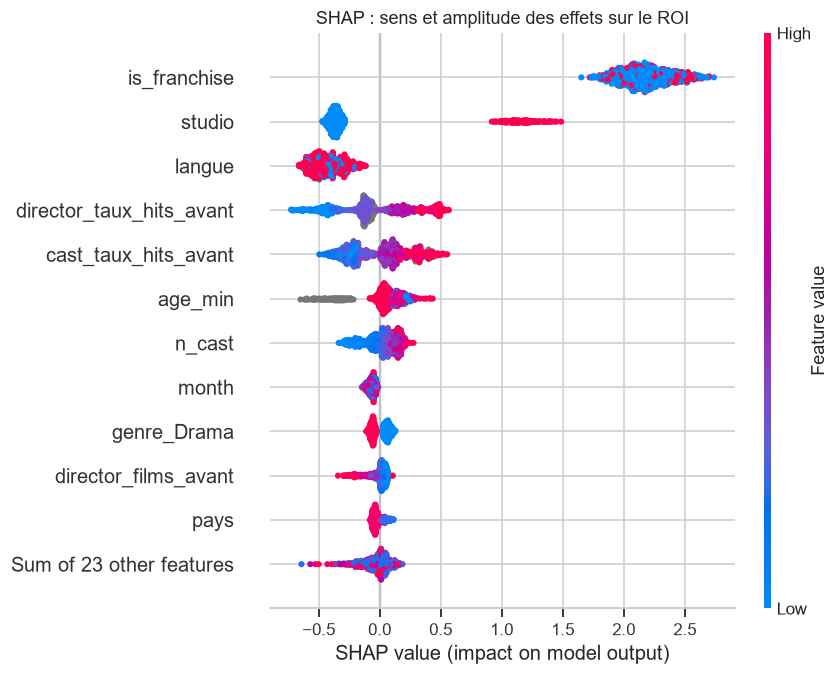

In [ ]:
explicateur = shap.TreeExplainer(recherche.best_estimator_)
explication = explicateur(X.loc[i_test])
explication.feature_names = variables

shap.plots.beeswarm(explication, max_display=12, show=False)
plt.title("SHAP : sens et amplitude des effets sur le ROI")
plt.tight_layout()

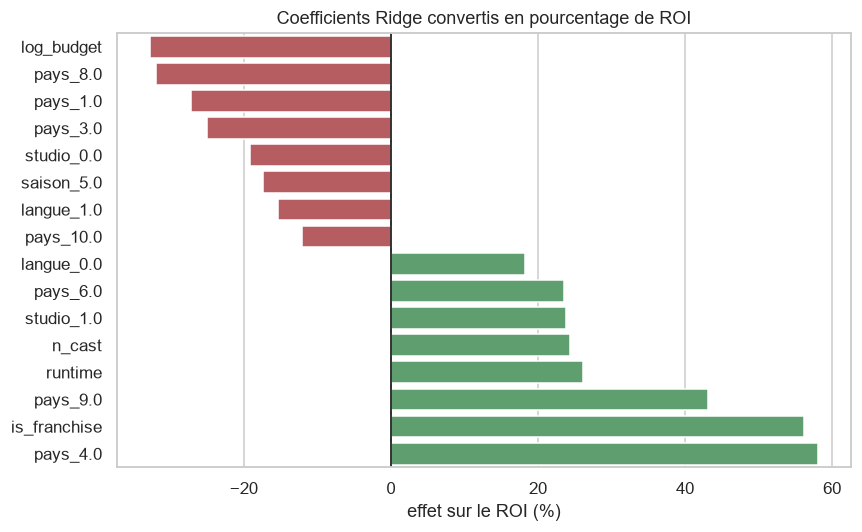

In [ ]:
ridge = finalistes["Ridge"]
noms = ridge.named_steps["prep"].get_feature_names_out()
coefficients = pd.Series(ridge.named_steps["modele"].coef_, index=noms)
extremes = pd.concat([coefficients.nlargest(8), coefficients.nsmallest(8)]).sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=(np.exp(extremes.values) - 1) * 100, y=[n.split("__")[-1] for n in extremes.index],
            hue=extremes.index, palette=["#C44E52" if v < 0 else "#55A868" for v in extremes.values], legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("effet sur le ROI (%)")
plt.title("Coefficients Ridge convertis en pourcentage de ROI")
plt.tight_layout()

Les coefficients de Ridge portent sur `log(ROI)` : en prenant l'exponentielle, ils se lisent en **pourcentage de ROI**. Un coefficient de 0,20 signifie +22 % de ROI, toutes choses égales par ailleurs.

## 11. Contrôle anti-fuite

In [ ]:
apres_sortie = pd.read_parquet(config.MOVIES_TABLE)[["movieId", "vote_count", "popularity", "revenue_2023"]]
elargi = data.merge(apres_sortie, on="movieId")

def mae_avec(colonnes):
    matrice = elargi[colonnes].copy()
    for colonne in colonnes:
        matrice[colonne] = (matrice[colonne].astype("category").cat.codes.astype("float64")
                            if colonne in categorielles else matrice[colonne].astype("float64"))
    cible = elargi["log_roi"].astype(float)
    avant, apres = elargi["year"] < 2018, elargi["year"] >= 2018
    modele = HistGradientBoostingRegressor(
        categorical_features=[colonnes.index(c) for c in categorielles], random_state=42)
    modele.fit(matrice[avant], cible[avant])
    return mean_absolute_error(cible[apres], modele.predict(matrice[apres]))

comparaison = pd.DataFrame([
    {"variables utilisées": "34 variables pré-production", "MAE": mae_avec(variables)},
    {"variables utilisées": "+ nombre de votes et popularité", "MAE": mae_avec(variables + ["vote_count", "popularity"])},
    {"variables utilisées": "+ recettes", "MAE": mae_avec(variables + ["revenue_2023"])},
]).set_index("variables utilisées")
comparaison["facteur d'erreur"] = np.exp(comparaison["MAE"])
comparaison.round(3)

,MAE,facteur d'erreur
variables utilisées,,
34 variables pré-production,1.233,3.431
+ nombre de votes et popularité,1.097,2.995
+ recettes,0.065,1.067


Avec les recettes, l'erreur s'effondre : le modèle recopie la réponse, puisque le ROI en découle directement. Ces variables sont inconnues avant la production, donc interdites.

## 12. Enregistrement du modèle retenu

In [ ]:
import json

from boxoffice.models import succes as modele_succes

mesures = pd.DataFrame(evaluation).set_index("modèle").loc[retenu].to_dict()
carte = modele_succes.sauvegarder(
    recherche.best_estimator_, variables, metriques=mesures, cible="log_roi",
    description="ROI d'un film en dollars constants 2023, variables pré-production, test temporel à partir de 2018",
    nom=modele_succes.REGRESSION)

print(json.dumps({champ: valeur for champ, valeur in carte.items() if champ != "variables"},
                 ensure_ascii=False, indent=2))

{
  "cible": "log_roi",
  "description": "ROI d'un film en dollars constants 2023, variables pré-production, test temporel à partir de 2018",
  "modele": "HistGradientBoostingRegressor",
  "hyperparametres": {
    "categorical_features": [
      2,
      5,
      6,
      7
    ],
    "early_stopping": true,
    "interaction_cst": null,
    "l2_regularization": 10.0,
    "learning_rate": 0.05,
    "loss": "squared_error",
    "max_bins": 255,
    "max_depth": null,
    "max_features": 1.0,
    "max_iter": 200,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 10,
    "monotonic_cst": null,
    "n_iter_no_change": 10,
    "quantile": null,
    "random_state": 42,
    "scoring": "loss",
    "tol": 1e-07,
    "validation_fraction": 0.1,
    "verbose": 0,
    "warm_start": false
  },
  "seuil_decision": null,
  "metriques": {
    "MAE": 1.2268,
    "facteur d'erreur": 3.4102,
    "RMSE": 1.7541,
    "R2": 0.1512
  },
  "entraine_le": "2026-09-18T14:40:05+00:00",
  "versions": {
    "scikit

In [ ]:
modele_relu, carte_relue = modele_succes.charger(modele_succes.REGRESSION)
exemple = X.loc[i_test].head(5)

pd.DataFrame({
    "film": data.loc[exemple.index, "title"].values,
    "ROI prédit": np.exp(modele_relu.predict(exemple)).round(2),
    "ROI réel": np.exp(y[exemple.index]).round(2).values,
})

,film,ROI prédit,ROI réel
0,Black Panther,4.52,6.75
1,Captain Marvel,3.17,7.44
2,Avengers: Infinity War,3.80,6.84
3,Avengers: Endgame,4.05,7.86
4,Fantastic Beasts: The Crimes of Grindelwald,4.49,3.27


## 13. Conclusions

**À compléter après lecture des résultats :**
- les 5 variables les plus importantes et le sens de leur effet, en pourcentage de ROI ;
- le ROI attendu par genre et par tranche de budget, pour la direction ;
- ce que l'analyse des résidus a révélé (biais par année, par genre, écrasement des extrêmes) ;
- les limites : biais de sélection, recettes brutes et non bénéfice, incertitude intrinsèque du box-office.

**Complémentarité avec la classification :** la classification donne la probabilité de rentabilité (le risque), la régression donne le ROI attendu (le gain). Une variable qui ressort dans les deux modèles est un vrai critère de succès.